In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
import os
from matplotlib import colors

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'

In [3]:
outdir = '/cndd2/hex002/Luo_Development/hic_compartment/'

In [5]:
binall = np.load(f'{outdir}binfilter_raw.npy', allow_pickle=True)
comp = pd.read_hdf(f'{outdir}/comp_raw_mergerawpca.hdf', key='data')

In [7]:
res = 100_000
binall = pd.DataFrame(index=comp.index)
binall['chrom'] = binall.index.str.split('-').str[0]
binall['start'] = binall.index.str.split('-').str[1].astype(int) * res
binall['end'] = binall['start'] + res

## Create dcHic files

In [13]:
target_legs = {'DRD1-EPHA4':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-EPHA4','3T_Inh-MSN-DRD1-EPHA4','1m_Inh-MSN-DRD1-EPHA4','4-7m_Inh-MSN-DRD1-EPHA4','adult_Inh-MSN-DRD1-EPHA4'],
               'DRD1-BACH2':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-BACH2','3T_Inh-MSN-DRD1-BACH2','1m_Inh-MSN-DRD1-BACH2','4-7m_Inh-MSN-DRD1-BACH2','adult_Inh-MSN-DRD1-BACH2'],
               'DRD2-EPHA4':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-EPHA4','3T_Inh-MSN-DRD2-EPHA4','1m_Inh-MSN-DRD2-EPHA4','4-7m_Inh-MSN-DRD2-EPHA4','adult_Inh-MSN-DRD2-EPHA4'],
               'DRD2-BACH2':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD2-BACH2','3T_Inh-MSN-DRD2-BACH2','1m_Inh-MSN-DRD2-BACH2','4-7m_Inh-MSN-DRD2-BACH2','adult_Inh-MSN-DRD2-BACH2'],
               'DRD1-eccentric':['2T_Inh-MSN-eMSN','2T_Inh-MSN-DRD1-eccentric-CASZ1','3T_Inh-MSN-DRD1-eccentric-CASZ1','1m_Inh-MSN-DRD1-eccentric-CASZ1','4-7m_Inh-MSN-DRD1-eccentric-CASZ1','adult_Inh-MSN-DRD1-eccentric-CASZ1'],

               'MGE-PVALB':['2T_Inh-MGE-MGE','3T_Inh-MGE-PVALB','1m_Inh-MGE-PVALB','4-7m_Inh-MGE-PVALB','adult_Inh-MGE-PVALB'],
               'MGE-SST-THRDE':['2T_Inh-MGE-MGE','3T_Inh-MGE-SST-THRDE','1m_Inh-MGE-SST-THRDE','4-7m_Inh-MGE-SST-THRDE','adult_Inh-MGE-SST-THRDE'],
               'CGE-LAMP5':['2T_Inh-CGE-eCGE','3T_Inh-CGE-LAMP5','1m_Inh-CGE-LAMP5','4-7m_Inh-CGE-LAMP5','adult_Inh-CGE-LAMP5'],
               'CGE-VIP':['2T_Inh-CGE-eCGE','3T_Inh-CGE-VIP','1m_Inh-CGE-VIP','4-7m_Inh-CGE-VIP','adult_Inh-CGE-VIP'],
               'CGE-KCNJ1':['2T_Inh-CGE-eCGE','3T_Inh-CGE-KCNJ1','1m_Inh-CGE-KCNJ1','4-7m_Inh-CGE-KCNJ1','adult_Inh-CGE-KCNJ1'],
               "Exc-CUX2": ["2T_Exc-RG-1-RG-1", "3T_Exc-UL-L1-3-CUX2", "1m_Exc-UL-L1-3-CUX2", "4-7m_Exc-UL-L1-3-CUX2","adult_Exc-UL-L1-3-CUX2"],
               "Exc-RORB": ["2T_Exc-RG-1-RG-1",  "3T_Exc-UL-L4-RORB", "1m_Exc-UL-L4-RORB", "4-7m_Exc-UL-L4-RORB", "adult_Exc-UL-L4-RORB"],
               'Exc-TCF4':['2T_Exc-RG-1-RG-1','3T_Exc-DL-ENT-TCF4','1m_Exc-DL-ENT-TCF4','4-7m_Exc-DL-ENT-TCF4','adult_Exc-DL-ENT-TCF4'],
               'Exc-CDH10':['2T_Exc-RG-1-RG-1','3T_Exc-DL-ENT-CDH10','1m_Exc-DL-ENT-CDH10','4-7m_Exc-DL-ENT-CDH10','adult_Exc-DL-ENT-CDH10'],
               'Astro':['2T_Glial-Glial-RG','2T_Glial-Glial-Astro','3T_Glial-Glial-Astro','1m_Glial-Glial-Astro','4-7m_Glial-Glial-Astro','adult_Glial-Glial-Astro'],
               'OPC':['2T_Glial-Glial-RG','2T_Glial-Glial-OPC','3T_Glial-Glial-OPC','1m_Glial-Glial-OPC','4-7m_Glial-Glial-OPC','adult_Glial-Glial-OPC'],
               'ODC':['2T_Glial-Glial-RG','3T_Glial-Glial-ODC','1m_Glial-Glial-ODC','4-7m_Glial-Glial-ODC','adult_Glial-Glial-ODC'],
               'MGC-1':['2T_NN-NN-MGC-1','3T_NN-NN-MGC-1','1m_NN-NN-MGC-1','4-7m_NN-NN-MGC-1','adult_NN-NN-MGC-1'],
               'MGC-2':['2T_NN-NN-MGC-2','3T_NN-NN-MGC-2','1m_NN-NN-MGC-2','4-7m_NN-NN-MGC-2','adult_NN-NN-MGC-2'],
}

In [ ]:
for leg_name in target_legs.keys():
    for xx in target_legs[leg_name]:
        if xx not in comp.columns:
            print(f'{xx} not in comp')
            continue
        xx_tmp = xx.replace('-','_')
        os.makedirs(f'{outdir}Compartment_PCA_REVISION/{leg_name}/dcHic_{xx_tmp}_100Kb_pca/intra_pca/dcHic_{xx_tmp}_100Kb_mat/', exist_ok=True)
        tmp = binall.copy()
        tmp['pc'] = comp[xx]
        for c in chrom_sizes.index:
            tmp.loc[tmp['chrom']==c].to_csv(f'{outdir}Compartment_PCA_REVISION/{leg_name}/dcHic_{xx_tmp}_100Kb_pca/intra_pca/dcHic_{xx_tmp}_100Kb_mat/{c}.pc.bedGraph', sep='\t', header=False, index=False)

In [ ]:
for leg_name in target_legs.keys():
    legs = []
    for xx in target_legs[leg_name]:
        if xx in comp.columns:
            legs.append(xx)
    tmp = pd.DataFrame(index=legs)
    tmp['matrix_path'] = '.'
    tmp['bed_path'] = '.'
    tmp['sample'] = 'dcHic_' + tmp.index + '_100Kb'
    tmp['sample'] = tmp['sample'].str.replace('-','_')
    tmp['group'] = 'dcHic_' + tmp.index
    tmp['group'] = tmp['group'].str.replace('-','_')

    tmp.to_csv(f'{outdir}Compartment_PCA_REVISION/{leg_name}/input.txt', sep='\t', header=False, index=False)

In [ ]:
legs = list(target_legs.keys())   # your dict keys

bash_lines = [
    "#!/bin/bash",
    "set -euo pipefail",
    "",
    "",
]

for leg in legs:
    bash_lines += [
        f'echo "===== Running dcHiC for {leg} ====="',
        f"cd Compartment_PCA_REVISION/{leg}",
        "Rscript ../../dcHiC/dchicf.r --file input.txt --pcatype analyze --dirovwt T --diffdir .",
        "cd - > /dev/null",
        ""
    ]
bash_script = "\n".join(bash_lines)

with open("run_dchic.sh", "w") as f:
    f.write(bash_script)

print("Created run_dchic.sh")

## Exan Diff Compartment

In [15]:
all_results = []

for target in target_legs.keys():

    # -------------------------------------------------
    # Load dcHiC differential result
    # -------------------------------------------------
    diff_result = pd.read_csv(
        f'{outdir}Compartment_PCA_REVISION/{target}/DifferentialResult/fdr_result/'
        'differential.intra_sample_group.pcOri.bedGraph',
        sep='\t',
        index_col=0
    )

    # Z-score Mahalanobis distance
    diff_result['sample_maha_z'] = (
        diff_result['sample_maha'] - diff_result['sample_maha'].mean()
    ) / diff_result['sample_maha'].std()

    # Filter significant differential bins
    diff_result = diff_result[diff_result['sample_maha_z'] > 1.960]  # 97.5%

    # Build bin index
    diff_result["bin"] = diff_result.apply(
        lambda r: f"{r.name}:{int(r['start'])}-{int(r['end'])}", axis=1
    )
    diff_result = diff_result.set_index("bin")

    # Drop unused columns
    diff_result = diff_result.drop(
        columns=['start', 'end', 'sample_maha', 'pval', 'padj', 'dist_clust']
    )

    diff_result.columns = [c.replace("dcHic_", "") for c in diff_result.columns]

    diff_result = diff_result.iloc[:, :-1].T
    # -------------------------------------------------
    # Count sign flips between consecutive ages
    # -------------------------------------------------
    sign_mat = np.sign(diff_result.values)

    for i in range(sign_mat.shape[0] - 1):
        s1 = sign_mat[i]
        s2 = sign_mat[i + 1]

        a_to_b = np.sum((s1 > 0) & (s2 < 0))
        b_to_a = np.sum((s1 < 0) & (s2 > 0))

        all_results.append({
            "Target": target,
            "Age_pair": f"{diff_result.index[i]} → {diff_result.index[i+1]}",
            "A_to_B": a_to_b,
            "B_to_A": b_to_a,
            "Total_flips": a_to_b + b_to_a,
            "Num_bins_tested": diff_result.shape[1]
        })

# -------------------------------------------------
# Final summary table
# -------------------------------------------------
summary_df = pd.DataFrame(all_results)

In [17]:
def normalize_timepoint(label):
    """
    Map raw labels to canonical developmental stages.
    """
    label = str(label)

    if any(x in label for x in ["eMSN", "eMGE", "eCGE", "RG"]):
        return "2T_early"
    if "2T" in label:
        return "2T"
    if "3T" in label:
        return "3T"
    if "1m" in label:
        return "1m"
    if "4_7m" in label:
        return "4-7m"
    if "adult" in label:
        return "adult"

    raise ValueError(f"Unrecognized timepoint: {label}")

def target_priority(target):
    """
    Assign plotting priority based on biological class.
    Lower number = earlier in plot.
    """
    if target.startswith("DRD1"):
        return (0, target)
    if target.startswith("DRD2"):
        return (1, target)
    if target.startswith("CGE"):
        return (2, target)
    if target.startswith("MGE"):
        return (3, target)
    if target.startswith("Exc"):
        return (4, target)
    if target in ["OPC", "ODC"]:
        return (5, target)
    if target.startswith("Astro"):
        return (6, target)
    if target.startswith("MGC-1"):
        return (7, target)
    if target.startswith("MGC-2"):
        return (8, target)

    # fallback (if anything unexpected)
    return (99, target)

def normalize_age_pair(age_pair):
    """
    Convert raw age comparison into canonical form.
    Example: 'eMSN → 3T' → '2T → 3T'
    """
    left, right = age_pair.split("→")
    left = normalize_timepoint(left.strip())
    right = normalize_timepoint(right.strip())
    return f"{left} → {right}"


# =====================================================
# 2. Prepare plotting dataframe (COUNTS)
# =====================================================
plot_df = summary_df.copy()

plot_df = plot_df.melt(
    id_vars=["Target", "Age_pair"],
    value_vars=["A_to_B", "B_to_A"],
    var_name="Direction",
    value_name="Count"
)

plot_df["Direction"] = plot_df["Direction"].map({
    "A_to_B": "A → B",
    "B_to_A": "B → A"
})

# Normalize age labels
plot_df["Age_pair_clean"] = plot_df["Age_pair"].apply(normalize_age_pair)

# Collapse duplicated transitions
plot_df = (
    plot_df
    .groupby(["Target", "Age_pair_clean", "Direction"], as_index=False)
    .agg({"Count": "sum"})
)

# Enforce biological order
age_order = ["2T_early → 2T","2T_early → 3T","2T → 3T", "3T → 1m", "1m → 4-7m", "4-7m → adult"]
plot_df["Age_pair_clean"] = pd.Categorical(
    plot_df["Age_pair_clean"],
    categories=age_order,
    ordered=True
)
# pivot to wide format
wide_df = (
    plot_df
    .pivot_table(
        index=["Target", "Age_pair_clean"],
        columns="Direction",
        values="Count",
        fill_value=0
    )
    .reset_index()
)
wide_df["target_order"] = wide_df["Target"].apply(target_priority)

wide_df = wide_df.sort_values("target_order").drop(columns="target_order")

/tmp/ipykernel_3567492/2307082534.py:96: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  plot_df


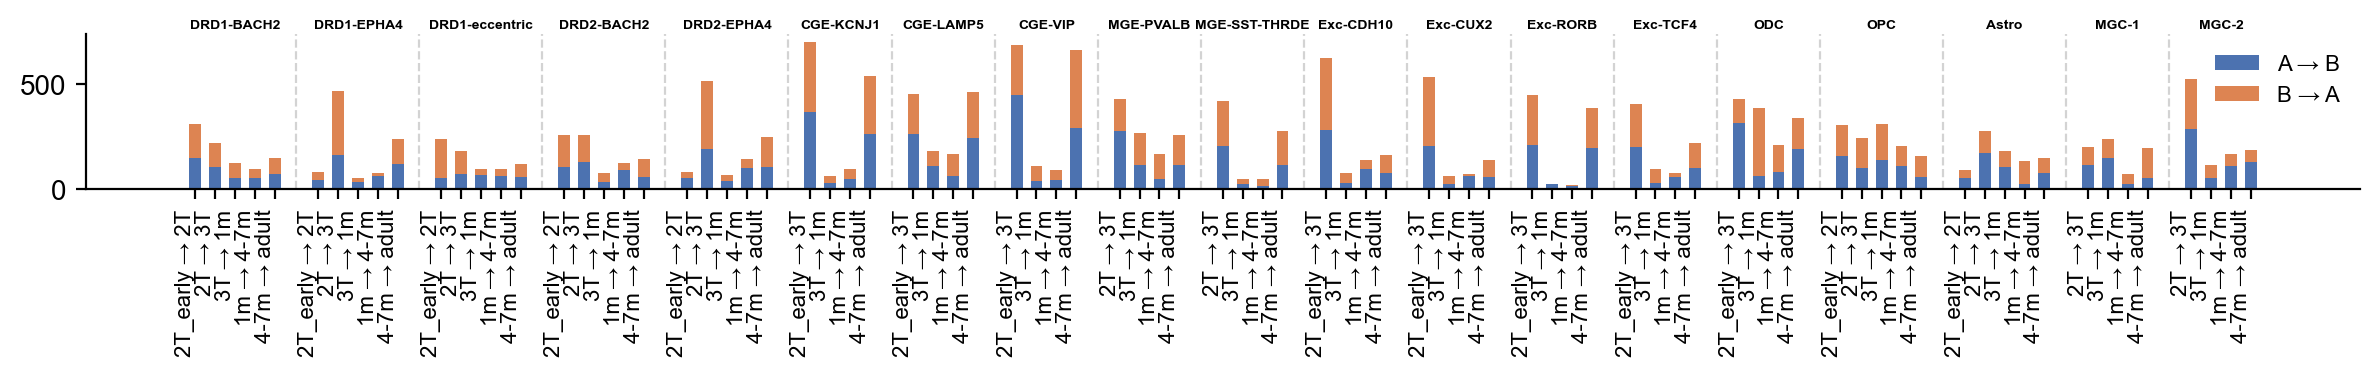

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

colors = {
    "A → B": "#4C72B0",
    "B → A": "#DD8452"
}

gap = 1.2          # space between targets
bar_width = 0.6

x_positions = []
x_labels = []
target_centers = []
target_boundaries = []   # for vertical lines

x_cursor = 0

fig, ax = plt.subplots(figsize=(12, 2), dpi=200)

targets = wide_df["Target"].drop_duplicates().tolist()

for ti, target in enumerate(targets):

    df_t = (
        wide_df[wide_df["Target"] == target]
        .sort_values("Age_pair_clean")
        .reset_index(drop=True)
    )
    n = len(df_t)

    xs = np.arange(x_cursor, x_cursor + len(df_t))

    # record positions
    x_positions.extend(xs)
    x_labels.extend(df_t["Age_pair_clean"].tolist())
    target_centers.append(xs.mean())

    # stacked bars
    ax.bar(
        xs,
        df_t["A → B"],
        width=bar_width,
        color=colors["A → B"],
        label="A → B" if ti == 0 else None
    )
    ax.bar(
        xs,
        df_t["B → A"],
        bottom=df_t["A → B"],
        width=bar_width,
        color=colors["B → A"],
        label="B → A" if ti == 0 else None
    )

    # record boundary for separator (except last target)
    target_boundaries.append(x_cursor + n - 0.5)

    # move cursor
    x_cursor += n + gap


# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=90, ha="right", fontsize=8)

# ax.set_ylabel("Number of bins")
# ax.set_xlabel("Developmental transition")
# ax.set_title("Compartment switching across development", fontsize=12)

# -------------------------------------------------
# Vertical separator lines between targets
# -------------------------------------------------
ymin, ymax = ax.get_ylim()

for xb in target_boundaries[:-1]:
    ax.axvline(
        xb + gap / 2,
        color="lightgray",
        linewidth=0.8,
        linestyle="--",
        zorder=0
    )

# -------------------------------------------------
# Target labels at TOP
# -------------------------------------------------
for center, target in zip(target_centers, targets):
    ax.text(
        center,
        ymax * 1.02,
        target,
        ha="center",
        va="bottom",
        fontsize=5,
        fontweight="bold",
        clip_on=False
    )

# -------------------------------------------------
# Clean up aesthetics
# -------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False, fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

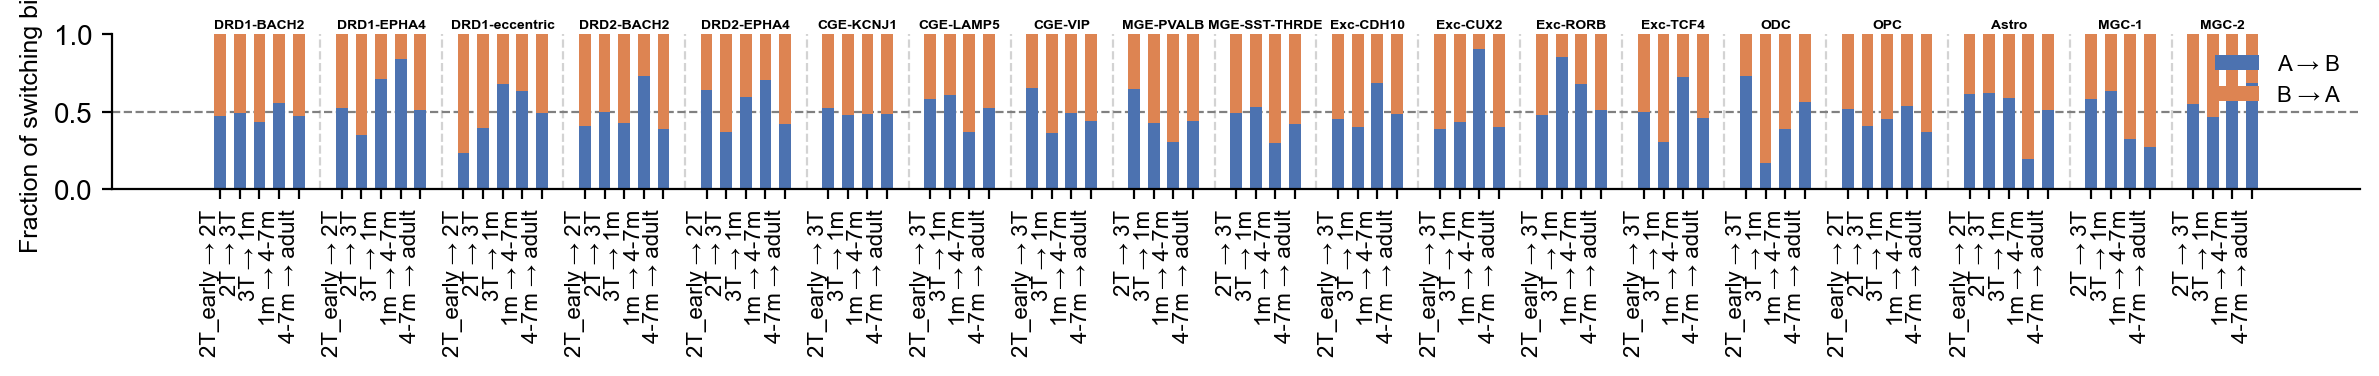

In [19]:
import numpy as np
import matplotlib.pyplot as plt

colors = {
    "A → B": "#4C72B0",
    "B → A": "#DD8452"
}

gap = 1.2
bar_width = 0.6

x_positions = []
x_labels = []
target_centers = []
target_boundaries = []

x_cursor = 0

fig, ax = plt.subplots(figsize=(12, 2), dpi=200)

targets = wide_df["Target"].drop_duplicates().tolist()

for ti, target in enumerate(targets):

    df_t = (
        wide_df[wide_df["Target"] == target]
        .sort_values("Age_pair_clean")
        .reset_index(drop=True)
    )
    n = len(df_t)

    xs = np.arange(x_cursor, x_cursor + n)

    # ----- compute ratios -----
    total = df_t["A → B"] + df_t["B → A"]
    ratio_A2B = df_t["A → B"] / total
    ratio_B2A = df_t["B → A"] / total

    # record positions
    x_positions.extend(xs)
    x_labels.extend(df_t["Age_pair_clean"].tolist())
    target_centers.append(xs.mean())

    # stacked ratio bars (sum to 1)
    ax.bar(
        xs,
        ratio_A2B,
        width=bar_width,
        color=colors["A → B"],
        label="A → B" if ti == 0 else None
    )
    ax.bar(
        xs,
        ratio_B2A,
        bottom=ratio_A2B,
        width=bar_width,
        color=colors["B → A"],
        label="B → A" if ti == 0 else None
    )

    target_boundaries.append(x_cursor + n - 0.5)
    x_cursor += n + gap


# -------------------------------------------------
# Axis formatting
# -------------------------------------------------
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, rotation=90, ha="right", fontsize=8)

ax.set_ylim(0, 1)
ax.set_ylabel("Fraction of switching bins", fontsize=9)

# -------------------------------------------------
# Vertical separators
# -------------------------------------------------
ymin, ymax = ax.get_ylim()
for xb in target_boundaries[:-1]:
    ax.axvline(
        xb + gap / 2,
        color="lightgray",
        linewidth=0.8,
        linestyle="--",
        zorder=0
    )

# -------------------------------------------------
# Target labels on top
# -------------------------------------------------
for center, target in zip(target_centers, targets):
    ax.text(
        center,
        1.02,
        target,
        ha="center",
        va="bottom",
        fontsize=5,
        fontweight="bold",
        transform=ax.get_xaxis_transform()
    )

# -------------------------------------------------
# Clean aesthetics
# -------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.axhline(
    0.5,
    color="gray",
    linewidth=0.8,
    linestyle="--",
    zorder=0
)

ax.legend(frameon=False, fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()